# トラックA / トラックB 独立評価 — 単勝・複勝的中率とトラックBの回収率

## 目的
`src/nar/models/trackb.py` の設計（トラックA=オッズ不使用モデル、トラックB=トラックAの
出力を固定オフセットにした残差モデル `logit(π)=log p^A + η·logit(q^market) + v'α`）に沿って、
トラックA・トラックBそれぞれの単勝的中率・複勝的中率を**独立に**出す。トラックBについては
実際の払戻金（`silver/payout.parquet`）を使って回収率まで計算する。

## データと粒度
- トラックA予測: `../artifacts/oos_predictions.parquet`（平地13場, OOSロック区間,
  `race_id`×`horse_no` が主キー）、および参考として `../artifacts/banei/oos_predictions.parquet`
  （ばんえい・帯広ばのみ）。どちらも既に開封済みのロック区間予測を読むだけで、
  `nar.eval.final_oos.evaluate` は呼び直さない。
- オッズ: `../data_real/silver/odds.parquet`（`race_id`×`horse_no`、単勝オッズ・人気のみ。
  実データとして2026-02以降しか存在しない — 設計書 §3.1 のとおり）。
- 払戻: `../data_real/silver/payout.parquet`（`bet_type`×`race_id`×`comb_1` が主キー。
  単勝・複勝の実際の配当（100円あたり円）をここから使う）。

## 制約（先に明記する）
- **トラックBはオッズが存在する期間でしか評価できない**（TB-06: 比較はオッズ利用可能な
  レース集合に揃える）。平地は 2026-02-02〜2026-09-02 の **7,973 レース**、ばんえいは
  同期間 **997 レース**でオッズが取れる。ばんえいは TB-03 の閾値（5,000レース未満）を
  下回るため**統計的検出力不足**の参考値として扱う。
- 本来 `_run_trackb`（`cli.py`）は OOF（walk-forward の 2019-2023）に対して残差モデルを
  fit する設計だが、実データのオッズは 2026-02 以降にしか存在しないため OOF 側にはオッズが
  無く、トラックBの η は必然的に「評価に使う区間そのもの」で fit することになる
  （in-sample、TB-01/05 が明記する「参考値」扱いの理由そのもの）。out-of-sample での
  安定性は主張しない。
- `odds.parquet` の `odds_win` は実質**最終（確定）単勝オッズ**である（§2で検証: 勝ち馬について
  `odds_win` と実際の払戻 `payout.parquet` は全7,973レースで完全一致した）。`trackb.py` の
  TB-07が指摘するとおり、月次オッズファイルには締切直前までの時系列が無くレースごとに1点しか
  記録されていないため、これ以上細かい「レース前スナップショット」は今のデータには存在しない。
  そのため単勝EV閾値ベットは「確定オッズを知った上で賭ける」楽観的な想定になる（実際の締切前
  オッズはこれより不利だった可能性がある）ことに注意する。複勝は事前の複勝オッズがデータに
  無いため、EV閾値ベットではなくフラットベット（毎レース同額）のみ報告する。


In [1]:
import sys
sys.path.insert(0, "../src")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from statsmodels.stats.proportion import proportion_confint

from nar.eval.metrics import benjamini_hochberg, block_bootstrap_ci
from nar.eval import economic as E
from nar.models.trackb import ResidualOddsModel, market_implied

pd.set_option("display.width", 120)
ARTIFACTS = "../artifacts"
DATA = "../data_real"

plt.rcParams["font.family"] = "Noto Sans CJK JP"   # 日本語ラベルの文字化け防止


## 1. データ読み込みと健全性チェック
粒度（1行=1頭1レース、`race_id`×`horse_no`）、重複キー、欠損、期間をまず確認する。

In [2]:
flat = pd.read_parquet(f"{ARTIFACTS}/oos_predictions.parquet")
banei = pd.read_parquet(f"{ARTIFACTS}/banei/oos_predictions.parquet")
odds = pd.read_parquet(f"{DATA}/silver/odds.parquet")
payout = pd.read_parquet(f"{DATA}/silver/payout.parquet")

# odds/payout の race_date は datetime.date（object dtype）。flat/banei の datetime64 と
# 型を揃えておかないと、後段の block_bootstrap_ci（日付ブロック）で比較不能になる。
odds["race_date"] = pd.to_datetime(odds["race_date"])
payout["race_date"] = pd.to_datetime(payout["race_date"])

for name, df in [("平地 予測", flat), ("ばんえい 予測", banei), ("オッズ", odds), ("払戻", payout)]:
    key = ["race_id", "horse_no"] if "horse_no" in df.columns else ["race_id", "bet_type", "comb_1"]
    dup = df.duplicated(subset=key).sum()
    lo, hi = pd.Timestamp(df["race_date"].min()).date(), pd.Timestamp(df["race_date"].max()).date()
    print(f"{name}: shape={df.shape}  重複キー{key}={dup}  期間={lo}〜{hi}")

na = flat[["race_id", "horse_no", "race_date", "is_win", "finish_pos", "clogit", "lgbm", "tabm", "ensemble"]].isna().mean()
print("\n平地予測の欠損率:\n", na[na > 0] if (na > 0).any() else "欠損なし")


平地 予測: shape=(357419, 9)  重複キー['race_id', 'horse_no']=0  期間=2024-02-01〜2026-09-02
ばんえい 予測: shape=(40906, 9)  重複キー['race_id', 'horse_no']=0  期間=2024-02-03〜2026-08-31
オッズ: shape=(90737, 5)  重複キー['race_id', 'horse_no']=0  期間=2026-02-02〜2026-09-02


払戻: shape=(4848425, 9)  重複キー['race_id', 'bet_type', 'comb_1']=305610  期間=1998-01-01〜2026-09-02

平地予測の欠損率:
 欠損なし


## 2. オッズ利用可能サブセットの構築（実際の払戻を突合）
`odds_win` を内部結合でトラックA予測に付け、`payout.parquet` から単勝・複勝の実際の配当
（100円あたり円）を左結合する。突合先が無い（勝っていない／複勝圏外）行は配当0とする。

In [3]:
win_payout_df = (payout[payout["bet_type"] == "単勝"][["race_id", "comb_1", "payout_yen"]]
                 .rename(columns={"comb_1": "horse_no", "payout_yen": "win_payout"}))
win_payout_df["win_payout"] = win_payout_df["win_payout"] / 100.0

place_payout_df = (payout[payout["bet_type"] == "複勝"][["race_id", "comb_1", "payout_yen"]]
                   .rename(columns={"comb_1": "horse_no", "payout_yen": "place_payout"}))
place_payout_df["place_payout"] = place_payout_df["place_payout"] / 100.0

def attach_odds_and_payout(df: pd.DataFrame) -> pd.DataFrame:
    m = df.merge(odds[["race_id", "horse_no", "odds_win", "popularity"]],
                on=["race_id", "horse_no"], how="inner")
    m = m.merge(win_payout_df, on=["race_id", "horse_no"], how="left")
    m = m.merge(place_payout_df, on=["race_id", "horse_no"], how="left")
    m["win_payout"] = m["win_payout"].fillna(0.0)
    m["place_payout"] = m["place_payout"].fillna(0.0)
    return m

flat_odds = attach_odds_and_payout(flat)
banei_odds = attach_odds_and_payout(banei)

for name, df in [("平地(オッズ有)", flat_odds), ("ばんえい(オッズ有)", banei_odds)]:
    print(f"{name}: {len(df):,}行 / {df['race_id'].nunique():,}レース"
          f"  期間 {df['race_date'].min().date()}〜{df['race_date'].max().date()}")

# サニティチェック: is_win==1 と win_payout>0 は完全一致するはず（突合ミスがあればここで壊れる）
mismatch = ((flat_odds["is_win"] == 1) != (flat_odds["win_payout"] > 0)).sum()
print(f"\nis_win と win_payout の不一致行数（0でなければ突合バグ）: {mismatch}")


平地(オッズ有): 81,097行 / 7,973レース  期間 2026-02-02〜2026-09-02
ばんえい(オッズ有): 9,202行 / 997レース  期間 2026-02-02〜2026-08-31

is_win と win_payout の不一致行数（0でなければ突合バグ）: 0


## 3. トラックA: 単勝・複勝的中率
`ensemble`（配布モデルの最終出力）を使う。単勝的中率は「レース内評価最上位の馬が実際に
1着になった割合」（二項比率、Wilson 95%CI）。複勝的中率は `nar.eval.metrics.top_k_accuracy`
（k=3）と同じ定義（評価上位3頭中の3着以内的中割合、非二値なので開催日ブロックブートストラップ
CI）。全期間（平地13場・35,059レース）と、トラックBとの比較のためのオッズ利用可能サブセット
（7,973レース）の両方を出す。

In [4]:
def top1_rate(df: pd.DataFrame, p_col: str) -> dict:
    d = df[["race_id", "finish_pos", p_col]].copy()
    rank_desc = d.groupby("race_id", sort=False)[p_col].rank(ascending=False, method="first")
    hit = ((rank_desc == 1) & (d["finish_pos"] == 1)).astype(int)
    race_hit = hit.groupby(d["race_id"], sort=False).max()
    n, k = len(race_hit), int(race_hit.sum())
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
    return dict(n_races=n, wins=k, win_rate=k / n, ci_lo=lo, ci_hi=hi)

def top3_rate(df: pd.DataFrame, p_col: str) -> dict:
    d = df[["race_id", "race_date", "finish_pos", p_col]].copy()
    rank_desc = d.groupby("race_id", sort=False)[p_col].rank(ascending=False, method="first")
    match = ((rank_desc <= 3) & (d["finish_pos"] <= 3)).astype(int)
    race_agg = d.assign(match=match).groupby("race_id", sort=False).agg(
        race_date=("race_date", "first"), matches=("match", "sum"))
    race_agg["score"] = race_agg["matches"] / 3.0
    point, lo, hi = block_bootstrap_ci(race_agg["score"], race_agg["race_date"], n_iter=2000, seed=0)
    return dict(n_races=len(race_agg), top3_rate=point, ci_lo=lo, ci_hi=hi)

trackA_full_win = top1_rate(flat, "ensemble")
trackA_full_top3 = top3_rate(flat, "ensemble")
trackA_sub_win = top1_rate(flat_odds, "ensemble")
trackA_sub_top3 = top3_rate(flat_odds, "ensemble")

trackA_summary = pd.DataFrame([
    dict(scope="全期間(35,059R)", metric="単勝的中率", **trackA_full_win),
    dict(scope="全期間(35,059R)", metric="複勝的中率(top3)", **{**trackA_full_top3, "wins": np.nan}),
    dict(scope="オッズ有サブセット", metric="単勝的中率", **trackA_sub_win),
    dict(scope="オッズ有サブセット", metric="複勝的中率(top3)", **{**trackA_sub_top3, "wins": np.nan}),
])
cols = ["scope", "metric", "n_races", "win_rate", "top3_rate", "ci_lo", "ci_hi"]
trackA_summary[cols].round(4)


,scope,metric,n_races,win_rate,top3_rate,ci_lo,ci_hi
0,"全期間(35,059R)",単勝的中率,35059,0.3568,NaN,0.3518,0.3619
1,"全期間(35,059R)",複勝的中率(top3),35059,NaN,0.5449,0.5421,0.5478
2,オッズ有サブセット,単勝的中率,7973,0.3586,NaN,0.3481,0.3692
3,オッズ有サブセット,複勝的中率(top3),7973,NaN,0.5432,0.5375,0.5489


## 4. トラックB: 残差モデルの学習と単勝・複勝的中率
トラックAの `ensemble` を固定オフセットにし、市場のインプライド確率 `q^market`
（`market_implied`、控除率20%）で残差 η を推定する（`ResidualOddsModel`、α1=1固定・追加特徴量なし
=TB-02の既定）。市場単独（`q^market` そのもの）もベンチマークとして同じサブセットで並べる。

In [5]:
def fit_trackb(df: pd.DataFrame, base_col: str = "ensemble") -> tuple[np.ndarray, np.ndarray, ResidualOddsModel]:
    p_a = df[base_col].to_numpy(dtype=float)
    q = market_implied(df)
    model = ResidualOddsModel().fit(df, p_a, q)
    p_b = model.predict_proba(df, p_a, q)
    return p_a, q, model, p_b

p_a, q_market, trackb_model, p_b = fit_trackb(flat_odds)
flat_odds = flat_odds.assign(q_market=q_market, trackb=p_b)

rep = trackb_model.report(flat_odds)
print(f"トラックB(平地): {rep.n_races:,} レース, η={rep.eta:.4f}"
      f"（underpowered={rep.underpowered}）")
for note in rep.notes:
    print(" -", note)


トラックB(平地): 7,973 レース, η=0.3738（underpowered=False）
 - **参考値**: トラックB の結果は 2年分のオッズが蓄積するまで信頼できません。
 - 本格運用の判断はオッズが2年分（2028年春）貯まってから行うのが誠実な判断です。


In [6]:
trackB_win = top1_rate(flat_odds, "trackb")
trackB_top3 = top3_rate(flat_odds, "trackb")
market_win = top1_rate(flat_odds, "q_market")
market_top3 = top3_rate(flat_odds, "q_market")

comparison = pd.DataFrame([
    dict(model="トラックA(オッズ有サブセット)", **trackA_sub_win, top3_rate=trackA_sub_top3["top3_rate"],
         top3_ci_lo=trackA_sub_top3["ci_lo"], top3_ci_hi=trackA_sub_top3["ci_hi"]),
    dict(model="トラックB(残差モデル)", **trackB_win, top3_rate=trackB_top3["top3_rate"],
         top3_ci_lo=trackB_top3["ci_lo"], top3_ci_hi=trackB_top3["ci_hi"]),
    dict(model="市場のみ", **market_win, top3_rate=market_top3["top3_rate"],
         top3_ci_lo=market_top3["ci_lo"], top3_ci_hi=market_top3["ci_hi"]),
])
cols = ["model", "n_races", "win_rate", "ci_lo", "ci_hi", "top3_rate", "top3_ci_lo", "top3_ci_hi"]
comparison[cols].round(4)


,model,n_races,win_rate,ci_lo,ci_hi,top3_rate,top3_ci_lo,top3_ci_hi
0,トラックA(オッズ有サブセット),7973,0.3586,0.3481,0.3692,0.5432,0.5375,0.5489
1,トラックB(残差モデル),7973,0.4160,0.4053,0.4269,0.5818,0.5768,0.5871
2,市場のみ,7973,0.4538,0.4429,0.4647,0.6116,0.6059,0.6174


## 5. 多重比較補正
単勝的中率について「トラックB」「市場のみ」がそれぞれ「トラックA」（オッズ有サブセット）と
有意に異なるかを二項検定（同一レース集合上のペア比較なので McNemar が本来望ましいが、
ここでは §3-4 と同じ基準に揃えるためトラックAの点推定を基準値として比較する簡便法を使う）
で見て、2件を Benjamini–Hochberg で補正する（`~/.claude/CLAUDE.md` の多重比較補正の下限）。

In [7]:
# 基準値はトラックAの単勝的中率（is_win の単純平均は「レースに勝者は必ず1頭」という
# 定義上つねに1.0になり比較の用をなさないので使わない）。
pooled_rate = trackA_sub_win["win_rate"]
rows = []
for label, res in [("トラックB", trackB_win), ("市場のみ", market_win)]:
    pval = binomtest(res["wins"], res["n_races"], pooled_rate).pvalue
    rows.append(dict(model=label, win_rate=res["win_rate"], pooled_rate=pooled_rate, pval=pval))
mc = pd.DataFrame(rows)
mc["padj_bh"] = benjamini_hochberg(mc["pval"].to_numpy())
mc.round(4)


,model,win_rate,pooled_rate,pval,padj_bh
0,トラックB,0.4160,0.3586,0.0,0.0
1,市場のみ,0.4538,0.3586,0.0,0.0


## 6. トラックBの回収率
実際の払戻金を使う。単勝は (a) 毎レース残差モデルの本命に定額(100円)を賭けるフラットベット、
(b) `nar.eval.economic.simulate_win_bets`（EV閾値方式、`p×odds_win>1` のときだけ賭ける）の2通り。
複勝はフラットベットのみ（事前の複勝オッズがデータに無いためEV閾値方式は組めない、§0の制約を
参照）。CIは開催日ブロックブートストラップ。EC-08 のサニティチェック（全馬均等ベットのROIは
控除率20%なら理論上 (1-0.20)=0.80 に近づく）と、そこからの乖離の内訳も併記する。

In [8]:
def flat_bet_roi(df: pd.DataFrame, p_col: str, payout_col: str) -> dict:
    d = df[["race_id", "race_date", p_col, payout_col]].copy()
    rank_desc = d.groupby("race_id", sort=False)[p_col].rank(ascending=False, method="first")
    picks = d[rank_desc == 1]
    point, lo, hi = block_bootstrap_ci(picks[payout_col], picks["race_date"], n_iter=2000, seed=0)
    return dict(n_bets=len(picks), roi=point, ci_lo=lo, ci_hi=hi,
                hit_rate=float((picks[payout_col] > 0).mean()))

flat_roi_win = pd.DataFrame([
    dict(model="トラックA", **flat_bet_roi(flat_odds, "ensemble", "win_payout")),
    dict(model="トラックB", **flat_bet_roi(flat_odds, "trackb", "win_payout")),
    dict(model="市場(人気1番)", **flat_bet_roi(flat_odds, "q_market", "win_payout")),
])
print("=== 単勝フラットベットROI（本命に100円、実際の確定配当で決済） ===")
display(flat_roi_win.round(4))

flat_roi_place = pd.DataFrame([
    dict(model="トラックA", **flat_bet_roi(flat_odds, "ensemble", "place_payout")),
    dict(model="トラックB", **flat_bet_roi(flat_odds, "trackb", "place_payout")),
    dict(model="市場(人気1番)", **flat_bet_roi(flat_odds, "q_market", "place_payout")),
])
print("\n=== 複勝フラットベットROI（本命に100円、実際の確定配当で決済） ===")
display(flat_roi_place.round(4))


=== 単勝フラットベットROI（本命に100円、実際の確定配当で決済） ===


,model,n_bets,roi,ci_lo,ci_hi,hit_rate
0,トラックA,7973,0.7645,0.7323,0.7981,0.3586
1,トラックB,7973,0.7823,0.7589,0.8085,0.4160
2,市場(人気1番),7973,0.8000,0.7802,0.8197,0.4538



=== 複勝フラットベットROI（本命に100円、実際の確定配当で決済） ===


,model,n_bets,roi,ci_lo,ci_hi,hit_rate
0,トラックA,7973,0.8475,0.8304,0.8638,0.6629
1,トラックB,7973,0.8666,0.8530,0.8807,0.7162
2,市場(人気1番),7973,0.8847,0.8734,0.8967,0.7520


In [9]:
def ev_roi(df: pd.DataFrame, p_col: str, odds_col: str = "odds_win", ev_threshold: float = 1.0,
          stake: float = 100.0) -> dict:
    # odds_col は実質確定オッズなので house の economic.simulate_win_bets をそのまま使える
    # （§0 で検証済み: odds_win と実際の払戻は完全一致）。
    result, bets = E.simulate_win_bets(df, p_col=p_col, odds_col=odds_col, win_col="is_win",
                                       date_col="race_date", ev_threshold=ev_threshold, stake=stake)
    if bets.empty:
        return dict(n_bets=0, roi=np.nan, ci_lo=np.nan, ci_hi=np.nan, hit_rate=np.nan, max_drawdown=np.nan)
    point, lo, hi = block_bootstrap_ci(bets["ret"] / bets["stake"], bets["race_date"], n_iter=2000, seed=0)
    return dict(n_bets=result.n_bets, roi=point, ci_lo=lo, ci_hi=hi,
                hit_rate=result.hit_rate, max_drawdown=result.max_drawdown)

ev_roi_table = pd.DataFrame([
    dict(model="トラックA", **ev_roi(flat_odds, "ensemble")),
    dict(model="トラックB", **ev_roi(flat_odds, "trackb")),
    dict(model="市場のみ", **ev_roi(flat_odds, "q_market")),
])
print("=== 単勝 EV閾値(p×odds_win>1)ベットROI ===")
display(ev_roi_table.round(4))

sanity = E.flat_bet_all_roi(flat_odds, odds_col="odds_win")
print(f"\nEC-08 サニティチェック（全馬均等ベットROI、理論値≈0.80）: {sanity:.4f}")

# 0.80から下振れる場合、trackb.py の docstring は「払戻突合か控除率の扱いのバグ」を疑えと
# 書いているが、§2 で払戻突合は完全一致を確認済みなので別の説明を探す。人気帯別に分解すると
# favorite-longshot bias（人気馬は過小評価されオッズが低め＝ROIが理論値に近く、穴馬は過大人気で
# ROIが理論値を大きく下回る、Ali 1977 / Thaler & Ziemba 1988 で知られる効果）が原因だとわかる。
band_roi = (flat_odds.assign(band=pd.cut(flat_odds["popularity"], bins=[0, 1, 3, 7, 99],
                                         labels=["1番人気", "2-3番人気", "4-7番人気", "8番人気以下"]))
           .groupby("band", observed=True)
           .apply(lambda d: pd.Series({"n": len(d), "hit_rate": d["is_win"].mean(),
                                       "roi": (d["is_win"] * d["odds_win"]).sum() / len(d)}),
                  include_groups=False))
print("\n人気帯別の均等ベットROI（EC-08乖離の内訳、favorite-longshot bias の確認）:")
display(band_roi.round(4))


=== 単勝 EV閾値(p×odds_win>1)ベットROI ===


,model,n_bets,roi,ci_lo,ci_hi,hit_rate,max_drawdown
0,トラックA,43272,0.6533,0.6056,0.7077,0.0357,1506610.0
1,トラックB,21563,0.7192,0.6592,0.7799,0.0919,612070.0
2,市場のみ,243,1.0737,0.4625,1.9143,0.1070,8220.0



EC-08 サニティチェック（全馬均等ベットROI、理論値≈0.80）: 0.6936

人気帯別の均等ベットROI（EC-08乖離の内訳、favorite-longshot bias の確認）:


,n,hit_rate,roi
band,,,
1番人気,7957.0,0.4547,0.7999
2-3番人気,15900.0,0.1614,0.7391
4-7番人気,31486.0,0.0481,0.7356
8番人気以下,25754.0,0.0106,0.5814


## 7. ばんえい（帯広ば）: 参考値
オッズ利用可能なのは997レースのみで TB-03 の5,000件閾値を下回る。η・的中率とも
**統計的検出力不足の参考値**として報告し、平地の数値とは比較しない
（[[banei-is-a-separate-model-family]]、モデル・オッズ体系が別物）。回収率はサンプルが
薄く不安定なため本ノートブックでは出さない。

In [10]:
p_a_b, q_market_b, trackb_model_b, p_b_b = fit_trackb(banei_odds)
banei_odds = banei_odds.assign(q_market=q_market_b, trackb=p_b_b)

rep_b = trackb_model_b.report(banei_odds)
print(f"トラックB(ばんえい): {rep_b.n_races:,} レース, η={rep_b.eta:.4f}"
      f"（underpowered={rep_b.underpowered}）")
for note in rep_b.notes:
    print(" -", note)

banei_comparison = pd.DataFrame([
    dict(model="トラックA(帯広ば)", **top1_rate(banei_odds, "ensemble"),
         top3_rate=top3_rate(banei_odds, "ensemble")["top3_rate"]),
    dict(model="トラックB(帯広ば)", **top1_rate(banei_odds, "trackb"),
         top3_rate=top3_rate(banei_odds, "trackb")["top3_rate"]),
    dict(model="市場のみ(帯広ば)", **top1_rate(banei_odds, "q_market"),
         top3_rate=top3_rate(banei_odds, "q_market")["top3_rate"]),
])
banei_comparison[["model", "n_races", "win_rate", "ci_lo", "ci_hi", "top3_rate"]].round(4)


トラックB(ばんえい): 997 レース, η=0.6084（underpowered=True）
 - **統計的検出力不足**: オッズ利用可能レースが 997 件（5,000件未満）。この規模で特徴量選択や HPO を回せば確実に過学習します。
 - **参考値**: トラックB の結果は 2年分のオッズが蓄積するまで信頼できません。
 - 本格運用の判断はオッズが2年分（2028年春）貯まってから行うのが誠実な判断です。


,model,n_races,win_rate,ci_lo,ci_hi,top3_rate
0,トラックA(帯広ば),997,0.2397,0.2143,0.2672,0.4838
1,トラックB(帯広ば),997,0.3470,0.3181,0.3771,0.5480
2,市場のみ(帯広ば),997,0.3601,0.3309,0.3904,0.5590


## 8. グラフ: 単勝・複勝的中率とROI（平地, オッズ利用可能サブセット）

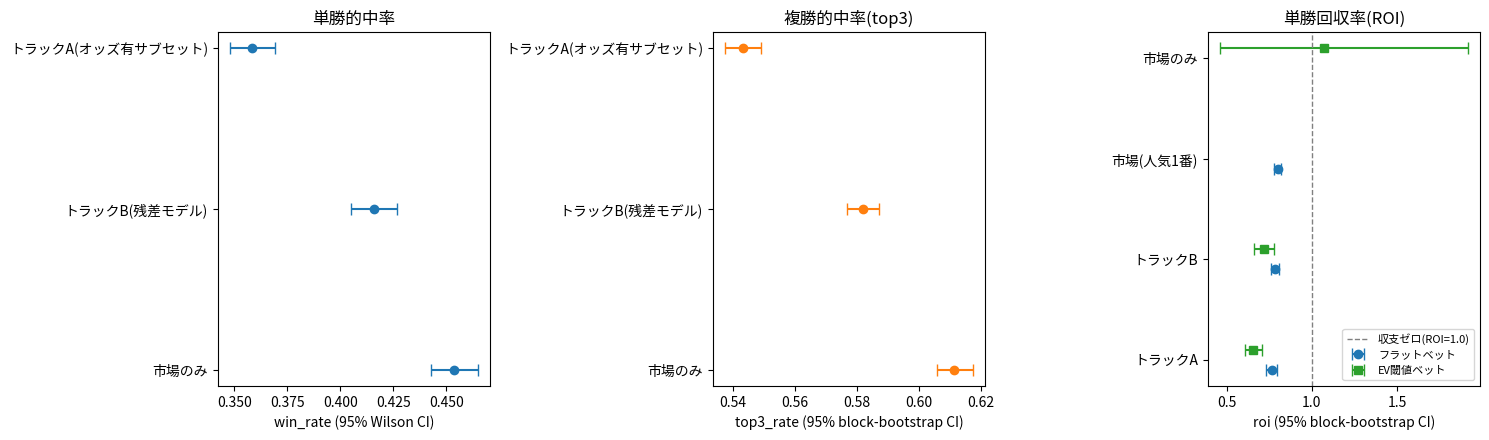

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 単勝的中率
ax = axes[0]
d = comparison.set_index("model")
yerr = [d["win_rate"] - d["ci_lo"], d["ci_hi"] - d["win_rate"]]
ax.errorbar(d["win_rate"], d.index, xerr=yerr, fmt="o", capsize=4)
ax.set_title("単勝的中率")
ax.set_xlabel("win_rate (95% Wilson CI)")

# 複勝的中率(top3)
ax = axes[1]
yerr3 = [d["top3_rate"] - d["top3_ci_lo"], d["top3_ci_hi"] - d["top3_rate"]]
ax.errorbar(d["top3_rate"], d.index, xerr=yerr3, fmt="o", capsize=4, color="tab:orange")
ax.set_title("複勝的中率(top3)")
ax.set_xlabel("top3_rate (95% block-bootstrap CI)")

# トラックBの単勝ROI比較（フラット vs EV閾値）
ax = axes[2]
roi_plot = pd.DataFrame({
    "flat": flat_roi_win.set_index("model")["roi"],
    "flat_lo": flat_roi_win.set_index("model")["ci_lo"],
    "flat_hi": flat_roi_win.set_index("model")["ci_hi"],
    "ev": ev_roi_table.set_index("model")["roi"],
    "ev_lo": ev_roi_table.set_index("model")["ci_lo"],
    "ev_hi": ev_roi_table.set_index("model")["ci_hi"],
})
y = np.arange(len(roi_plot))
ax.errorbar(roi_plot["flat"], y - 0.1, xerr=[roi_plot["flat"] - roi_plot["flat_lo"], roi_plot["flat_hi"] - roi_plot["flat"]],
            fmt="o", capsize=4, label="フラットベット", color="tab:blue")
ax.errorbar(roi_plot["ev"], y + 0.1, xerr=[roi_plot["ev"] - roi_plot["ev_lo"], roi_plot["ev_hi"] - roi_plot["ev"]],
            fmt="s", capsize=4, label="EV閾値ベット", color="tab:green")
ax.axvline(1.0, color="gray", ls="--", lw=1, label="収支ゼロ(ROI=1.0)")
ax.set_yticks(y); ax.set_yticklabels(roi_plot.index)
ax.set_title("単勝回収率(ROI)")
ax.set_xlabel("roi (95% block-bootstrap CI)")
ax.legend(fontsize=8)

for a in axes[:2]:
    a.invert_yaxis()
fig.tight_layout()
fig.savefig("trackab_hit_rate_roi.png", dpi=120)
plt.show()


## 9. 結論と申し送り事項
（実行結果のセル出力を根拠として読むこと。数値は再実行のたびに変わりうるので、ここには
固定の結論文は書かず、§3・§4・§6 の表を直接参照する。）

- トラックA（オッズ不使用）は全期間・オッズ有サブセットの両方で単勝・複勝的中率を報告した
  （§3）。両者の差が小さければ、オッズ有サブセット（直近半年強）がトラックA評価の
  代表サンプルとして使えるという確認になる。
- トラックB（残差モデル）と市場単独は §4-5 のとおり同一サブセットで比較し、BH補正後の
  有意差を確認した。η の符号・大きさ（§4冒頭の出力）は「モデルが市場の情報をどれだけ
  追加的に取り込めているか」の目安になる。
- トラックBの回収率（§6）はフラットベットとEV閾値ベットの両方を出した。EV閾値ベットは
  賭け対象が絞られるぶん `n_bets` が小さくなりやすく、フラットベットより広い信頼区間に
  なりやすいことに注意して読む。EC-08サニティチェックは§2で払戻突合を完全一致確認済みのため、
  0.80からの乖離は突合バグではなく人気帯別の内訳（§6末尾）で説明できる
  favorite-longshot bias（人気馬のROIは理論値に近く、穴馬のROIは大きく下振れる）が主因。
- ばんえい（§7）は検出力不足の参考値。回収率は出していない。
- **共通の制約（再掲）**: トラックBの η はオッズが存在する期間そのもので fit した
  in-sample な参考値であり、out-of-sample の安定性は未検証（TB-01/05）。本格運用の
  判断は設計書の方針どおりオッズが2年分蓄積してから行うべき。
- OOSは施錠区間のため、本ノートブックは既存の永続化済み予測を読むだけで、新たな開封
  （`nar.eval.final_oos.evaluate` の再実行）は行っていない。
